# Facial Keypoint Detection — BaselineCNN + Data Augmentation 

## 1. Imports

In [1]:
#%pip install torch torchvision

import os
import math
import pickle
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'Usando CUDA (NVIDIA GPU): {torch.cuda.get_device_name(0)}')
else:
    device = torch.device('cpu')
    print('CUDA no disponible, usando CPU.')

Usando CUDA (NVIDIA GPU): NVIDIA GeForce RTX 2070


## 2. Configuración

In [ ]:

DATA_DIR       = r'C:\Users\guill\OneDrive\Escritorio\repositorios-uni\deep-final-alpha\Data'
IMAGES_PATH    = os.path.join(DATA_DIR, 'preprocessed', 'images_50k.npy')
KEYPOINTS_PATH = os.path.join(DATA_DIR, 'preprocessed', 'keypoints_50k.npy')
MODEL_PATH     = os.path.join(DATA_DIR, 'best_baseline_augmented.pth')       
LOSSES_PATH    = os.path.join(DATA_DIR, 'training_losses_baseline_augmented.pkl')

IMG_SIZE    = 96
BATCH_SIZE  = 64
NUM_EPOCHS  = 20
LR          = 1e-3
SEED        = 42

# Hiperparámetros data augmentation
P_FLIP        = 0.5        # prob. de flip horizontal
P_ROTATE      = 0.5        # prob. de aplicar rotación
P_SHIFT       = 0.5        # prob. de aplicar desplazamiento
P_BRIGHTNESS  = 0.5        # prob. de alterar brillo
P_NOISE       = 0.3        # prob. de añadir ruido
MAX_ANGLE_DEG = 12.0       # rotación máxima (+/-) en grados
MAX_SHIFT_PX  = 6.0        # desplazamiento máximo (+/-) en píxeles
BRIGHT_RANGE  = (0.6, 1.4) # factor multiplicativo de brillo
NOISE_STD     = 0.02       # desviación del ruido 

print(f'IMAGES_PATH: {IMAGES_PATH}')
print(f'MODEL_PATH:  {MODEL_PATH}')
print(f'NUM_EPOCHS:  {NUM_EPOCHS}   BATCH_SIZE: {BATCH_SIZE}')

IMAGES_PATH: C:\Users\guill\OneDrive\Escritorio\repositorios-uni\deep-final-alpha\Data\preprocessed\images_50k.npy
MODEL_PATH:  C:\Users\guill\OneDrive\Escritorio\repositorios-uni\deep-final-alpha\Data\best_baseline_augmented.pth
NUM_EPOCHS:  20   BATCH_SIZE: 64


## 3. Carga de datos y split (mismo seed = 42)


In [ ]:
class FacialKeypointDataset(Dataset):
    def __init__(self, images, keypoints):
        self.images    = torch.tensor(images,    dtype=torch.float32)  # (N,3,96,96)
        self.keypoints = torch.tensor(keypoints, dtype=torch.float32)  # (N,136)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.keypoints[idx]


print('Cargando imágenes desde disco...')
images    = np.load(IMAGES_PATH)
keypoints = np.load(KEYPOINTS_PATH)
print(f'images:    {images.shape}   {images.nbytes / 1e9:.2f} GB')
print(f'keypoints: {keypoints.shape}')

full_dataset = FacialKeypointDataset(images, keypoints)
torch.manual_seed(SEED)
train_size = int(0.8 * len(full_dataset))
val_size   = len(full_dataset) - train_size
train_subset, val_subset = random_split(full_dataset, [train_size, val_size])
print(f'\nTrain: {len(train_subset):,}   Val: {len(val_subset):,}')

Cargando imágenes desde disco...
images:    (50000, 3, 96, 96)   5.53 GB
keypoints: (50000, 136)

Train: 40,000   Val: 10,000


## 4. Data augmentation (on-the-fly, solo en train)

In [ ]:

FLIP_IDX = torch.tensor([
    16,15,14,13,12,11,10,9,8,7,6,5,4,3,2,1,0,   # mandíbula 0-16
    26,25,24,23,22,                              # ceja der -> izq (17-21)
    21,20,19,18,17,                              # ceja izq -> der (22-26)
    27,28,29,30,                                 # puente nariz 27-30
    35,34,33,32,31,                              # base nariz 31-35
    45,44,43,42,47,46,                           # ojo der -> izq (36-41)
    39,38,37,36,41,40,                           # ojo izq -> der (42-47)
    54,53,52,51,50,49,48,                        # boca exterior 48-54
    59,58,57,56,55,                              # boca exterior 55-59
    64,63,62,61,60,                              # boca interior 60-64
    67,66,65,                                    # boca interior 65-67
], dtype=torch.long)
assert len(FLIP_IDX) == 68


def augment_sample(img, kps):
    """img: (3,96,96) en [0,1]; kps: (136,) normalizadas [0,1].
    Devuelve (img_aug, kps_aug) con keypoints transformados coherentemente."""
    kp = kps.view(68, 2).clone()   # filas = [x, y] normalizados

    # 1) Flip horizontal 
    if torch.rand(1).item() < P_FLIP:
        img = torch.flip(img, dims=[2])          # invierte el eje ancho
        kp[:, 0] = 1.0 - kp[:, 0]
        kp = kp[FLIP_IDX]

    # 2) Rotación y/o desplazamiento 
    ang = 0.0
    sx = sy = 0.0
    if torch.rand(1).item() < P_ROTATE:
        ang = (torch.rand(1).item() * 2 - 1) * MAX_ANGLE_DEG * math.pi / 180.0
    if torch.rand(1).item() < P_SHIFT:
        sx = (torch.rand(1).item() * 2 - 1) * MAX_SHIFT_PX / 48.0   # px -> normalizado
        sy = (torch.rand(1).item() * 2 - 1) * MAX_SHIFT_PX / 48.0
    if ang != 0.0 or sx != 0.0 or sy != 0.0:
        cos, sin = math.cos(ang), math.sin(ang)
        
        theta = torch.tensor([[cos, -sin, sx],
                              [sin,  cos, sy]], dtype=torch.float32).unsqueeze(0)
        grid = F.affine_grid(theta, img.unsqueeze(0).shape, align_corners=False)
        img = F.grid_sample(img.unsqueeze(0), grid, align_corners=False,
                            padding_mode='border')[0]
        
        Rinv = torch.tensor([[cos, sin], [-sin, cos]], dtype=torch.float32)
        tinv = -(Rinv @ torch.tensor([sx, sy], dtype=torch.float32))
        kc = kp * 2.0 - 1.0
        kc = kc @ Rinv.T + tinv
        kp = (kc + 1.0) / 2.0

    # 3) Brillo 
    if torch.rand(1).item() < P_BRIGHTNESS:
        factor = torch.empty(1).uniform_(*BRIGHT_RANGE).item()
        img = (img * factor).clamp(0.0, 1.0)

    # 4) Ruido 
    if torch.rand(1).item() < P_NOISE:
        img = (img + torch.randn_like(img) * NOISE_STD).clamp(0.0, 1.0)

    return img, kp.clamp(0.0, 1.0).reshape(-1)


class AugmentedDataset(Dataset):
    """Envuelve un Subset y aplica augmentation solo si augment=True."""
    def __init__(self, base_subset, augment):
        self.base = base_subset
        self.augment = augment

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, kps = self.base[idx]
        if self.augment:
            img, kps = augment_sample(img, kps)
        return img, kps


train_dataset = AugmentedDataset(train_subset, augment=True)   
val_dataset   = val_subset                                      

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f'Train (aumentado): {len(train_dataset):,}   Val (limpio): {len(val_dataset):,}')

Train (aumentado): 40,000   Val (limpio): 10,000


## 5. Verificación visual de la augmentation 

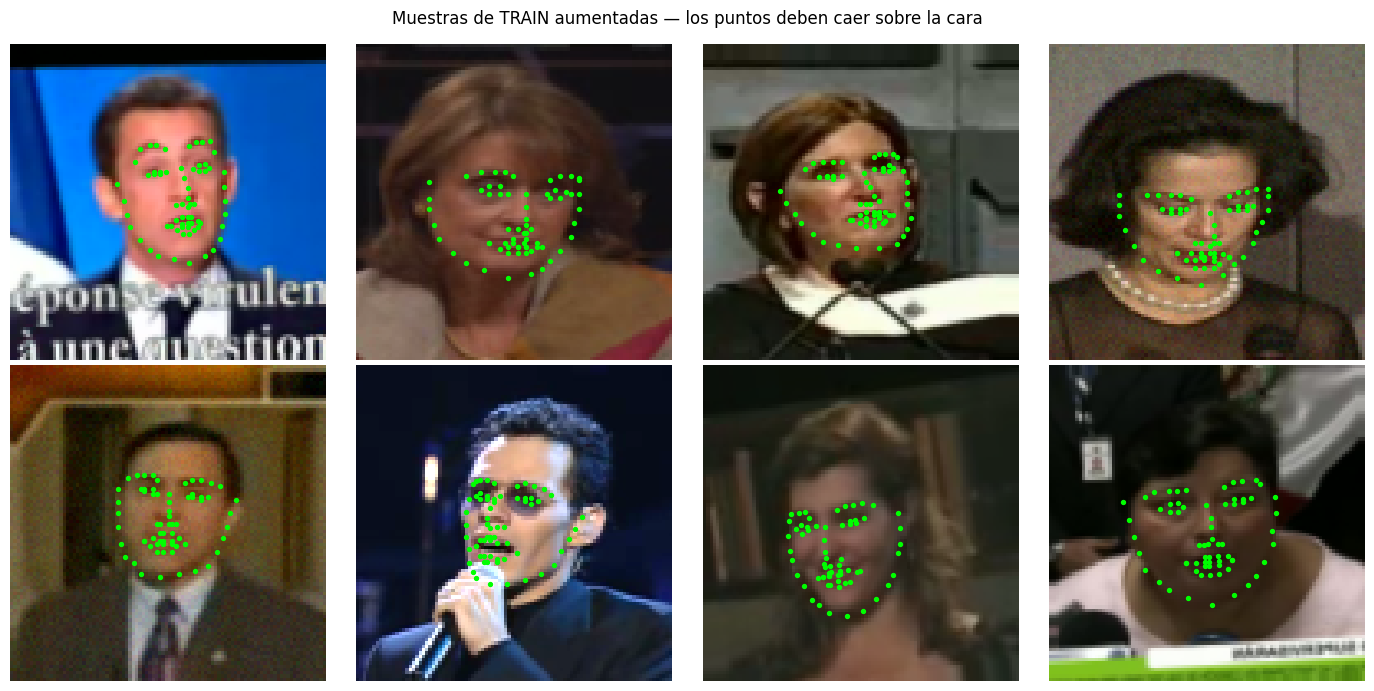

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax in axes.flatten():
    i = torch.randint(len(train_dataset), (1,)).item()
    img, kps = train_dataset[i]
    im  = img.numpy().transpose(1, 2, 0)
    pts = kps.view(68, 2).numpy() * IMG_SIZE
    ax.imshow(im)
    ax.scatter(pts[:, 0], pts[:, 1], s=8, c='lime')
    ax.axis('off')
plt.suptitle('Muestras de TRAIN aumentadas — los puntos deben caer sobre la cara', fontsize=12)
plt.tight_layout(); plt.show()

## 6. Modelo — BaselineCNN (idéntico al antiguo)

In [6]:
class BaselineCNN(nn.Module):
    def __init__(self, num_keypoints=68):
        super().__init__()
        out_dim = num_keypoints * 2
        self.features = nn.Sequential(
            nn.Conv2d(3,   32, kernel_size=3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32,  64, kernel_size=3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128,256, kernel_size=3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 1024), nn.ReLU(inplace=True),
            nn.Linear(1024, 256),          nn.ReLU(inplace=True),
            nn.Linear(256, out_dim),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.regressor(self.features(x))


model = BaselineCNN().to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parámetros entrenables: {total_params:,}')

with torch.no_grad():
    dummy = torch.zeros(4, 3, IMG_SIZE, IMG_SIZE).to(device)
    print(f'Input: {dummy.shape}  ->  Output: {model(dummy).shape}')

Parámetros entrenables: 10,123,976
Input: torch.Size([4, 3, 96, 96])  ->  Output: torch.Size([4, 136])


## 7. Loss y optimizador

In [7]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
print('Loss: MSELoss   Optimizer: Adam lr=1e-3   Scheduler: ReduceLROnPlateau')

Loss: MSELoss   Optimizer: Adam lr=1e-3   Scheduler: ReduceLROnPlateau


## 8. Entrenamiento

In [ ]:
best_val_loss = float('inf')
train_losses, val_losses = [], []

for epoch in range(1, NUM_EPOCHS + 1):

    #Train (con augmentation) 
    model.train()
    running_loss = 0.0
    for imgs, kps in train_loader:
        imgs, kps = imgs.to(device), kps.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), kps)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    train_loss = running_loss / len(train_dataset)

    #Validation (sin augmentation) 
    model.eval()
    running_val = 0.0
    with torch.no_grad():
        for imgs, kps in val_loader:
            imgs, kps = imgs.to(device), kps.to(device)
            running_val += criterion(model(imgs), kps).item() * imgs.size(0)
    val_loss = running_val / len(val_dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_PATH)
        saved_marker = '  ✅'
    else:
        saved_marker = ''

    print(f'Epoch {epoch:2d}/{NUM_EPOCHS}  '
          f'train: {train_loss:.6f}  val: {val_loss:.6f}  '
          f'lr: {current_lr:.2e}{saved_marker}')

print(f'\nMejor val_loss: {best_val_loss:.6f}')
print(f'Modelo guardado en: {MODEL_PATH}')

with open(LOSSES_PATH, 'wb') as f:
    pickle.dump({'train': train_losses, 'val': val_losses}, f)
print(f'Losses guardadas en: {LOSSES_PATH}')

Epoch  1/20  train: 0.002168  val: 0.000613  lr: 1.00e-03  ✅
Epoch  2/20  train: 0.000449  val: 0.000245  lr: 1.00e-03  ✅
Epoch  3/20  train: 0.000269  val: 0.000183  lr: 1.00e-03  ✅
Epoch  4/20  train: 0.000211  val: 0.000180  lr: 1.00e-03  ✅
Epoch  5/20  train: 0.000179  val: 0.000134  lr: 1.00e-03  ✅
Epoch  6/20  train: 0.000163  val: 0.000125  lr: 1.00e-03  ✅
Epoch  7/20  train: 0.000152  val: 0.000125  lr: 1.00e-03  ✅
Epoch  8/20  train: 0.000143  val: 0.000112  lr: 1.00e-03  ✅
Epoch  9/20  train: 0.000136  val: 0.000112  lr: 1.00e-03
Epoch 10/20  train: 0.000127  val: 0.000099  lr: 1.00e-03  ✅
Epoch 11/20  train: 0.000125  val: 0.000106  lr: 1.00e-03
Epoch 12/20  train: 0.000123  val: 0.000107  lr: 1.00e-03
Epoch 13/20  train: 0.000119  val: 0.000106  lr: 1.00e-03
Epoch 14/20  train: 0.000114  val: 0.000095  lr: 1.00e-03  ✅
Epoch 15/20  train: 0.000114  val: 0.000094  lr: 1.00e-03  ✅
Epoch 16/20  train: 0.000111  val: 0.000088  lr: 1.00e-03  ✅
Epoch 17/20  train: 0.000107  val: 0

## 9. Curva de pérdida

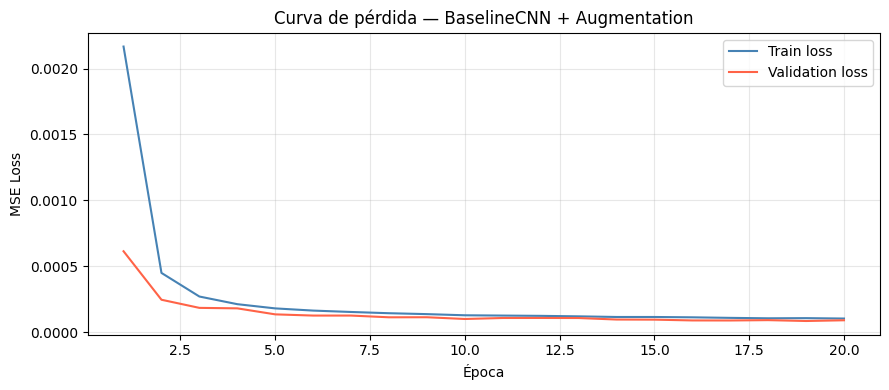

In [9]:
epochs = range(1, len(train_losses) + 1)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs, train_losses, label='Train loss',      color='steelblue')
ax.plot(epochs, val_losses,   label='Validation loss', color='tomato')
ax.set_xlabel('Época'); ax.set_ylabel('MSE Loss')
ax.set_title('Curva de pérdida — BaselineCNN + Augmentation')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()